Model: "teacher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 40, 200)        │     1,402,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 40, 200)        │       694,928 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 40, 200)        │           400 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40, 512)        │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 40, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7011)           │   143,592,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,792,731 (556.16 MB)

 Trainable params: 145,792,731 (556.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.0478 - loss: 7.6579 - val_accuracy: 0.0502 - val_loss: 8.6734 - learning_rate: 0.0010
Epoch 2/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.0509 - loss: 7.3502 - val_accuracy: 0.0502 - val_loss: 8.7381 - learning_rate: 0.0010
Epoch 3/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0516 - loss: 7.3011
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
662/662 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.0516 - loss: 7.3011 - val_accuracy: 0.0502 - val_loss: 8.7527 - learning_rate: 0.0010
Epoch 4/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.0531 - loss: 7.2245 - val_accuracy: 0.0502 - val_loss: 8.6848 - learning_rate: 2.0000e-04
Epoch 5/50
661/662 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0498 - loss: 7.1843
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
662/662 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.0498 -

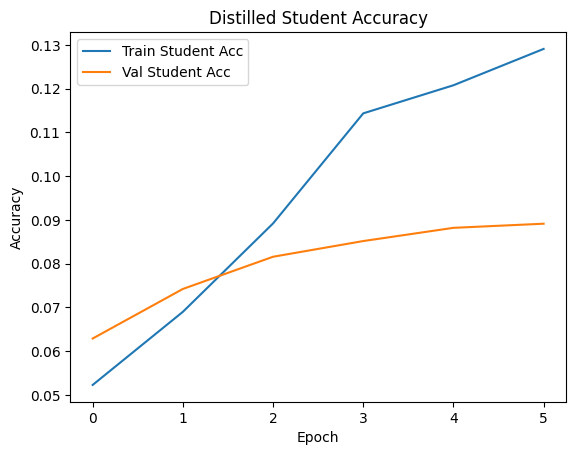

In [ ]:
# === Colab Block 1: Transformer Teacher + LSTM Student with Knowledge Distillation ===

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    MultiHeadAttention, LayerNormalization, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Data Loading & Preprocessing
data_path = 'ArticlesMarch2018.csv'
df = pd.read_csv(data_path)
df['snippet'] = df['snippet'].astype(str)

formatted_text = "\n".join(df['snippet'].tolist())
translator = str.maketrans('', '', string.punctuation)
formatted_text = formatted_text.translate(translator).lower()

# 2. Tokenization & Sequence Creation
tokenizer = Tokenizer()
tokenizer.fit_on_texts([formatted_text])
voc = len(tokenizer.word_index) + 1

input_sequences = []
for line in formatted_text.split('\n'):
    seq = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(seq)):
        input_sequences.append(seq[:i+1])

max_len = max(len(s) for s in input_sequences)
padded = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
X = padded[:, :-1]
y = to_categorical(padded[:, -1], num_classes=voc)

# 3. Callbacks
rlrong = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5, verbose=1)
estop   = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# 4. Build Transformer Teacher
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = Sequential([Dense(ff_dim, activation="relu"), Dense(embed_dim)])
        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)
        self.do1 = Dropout(rate)
        self.do2 = Dropout(rate)
    def call(self, inputs, training=None):
        attn = self.att(inputs, inputs)
        attn = self.do1(attn, training=training)
        out1 = self.ln1(inputs + attn)
        ffn = self.ffn(out1)
        ffn = self.do2(ffn, training=training)
        return self.ln2(out1 + ffn)

inp = Input(shape=(max_len-1,))
x = Embedding(voc, 200)(inp)
x = TransformerBlock(200, 4, 128)(x, training=True)
x = LayerNormalization(epsilon=1e-6)(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Flatten()(x)
teacher_out = Dense(voc, activation='softmax')(x)
teacher_model = Model(inp, teacher_out, name="teacher")
teacher_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
teacher_model.summary()

# 5. Train Teacher
teacher_history = teacher_model.fit(X, y, epochs=50, validation_split=0.2,
                                    callbacks=[rlrong, estop])

# 6. Build LSTM Student
student_inp = Input(shape=(max_len-1,))
s = Embedding(voc, 200)(student_inp)
s = LSTM(256)(s)
s = Dropout(0.2)(s)
student_logits = Dense(voc)(s)
student_model = Model(student_inp, student_logits, name="student")

# 7. Knowledge Distiller
teacher_model.trainable = False
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher, temperature=2.0, alpha=0.5):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.temperature = temperature
        self.alpha = alpha
        self.ce = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
        self.kld = tf.keras.losses.KLDivergence()
        self.acc = tf.keras.metrics.CategoricalAccuracy(name="student_accuracy")
    def compile(self, optimizer):
        super().compile(optimizer=optimizer)
    def train_step(self, data):
        x, y_true = data
        t_probs = self.teacher(x, training=False)
        t_logits = tf.math.log(t_probs + 1e-8)
        t_soft = tf.nn.softmax(t_logits / self.temperature)
        with tf.GradientTape() as tape:
            s_logits = self.student(x, training=True)
            s_soft = tf.nn.softmax(s_logits / self.temperature)
            loss_ce = self.ce(y_true, s_logits)
            loss_kld = self.kld(t_soft, s_soft)
            loss = self.alpha * (self.temperature**2) * loss_kld + (1-self.alpha)*loss_ce
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.acc.update_state(y_true, tf.nn.softmax(s_logits))
        return {"loss": loss, "student_accuracy": self.acc.result()}
    def test_step(self, data):
        x, y_true = data
        s_logits = self.student(x, training=False)
        loss = self.ce(y_true, s_logits)
        self.acc.update_state(y_true, tf.nn.softmax(s_logits))
        return {"loss": loss, "student_accuracy": self.acc.result()}

distiller = Distiller(student_model, teacher_model, temperature=2.0, alpha=0.5)
distiller.compile(optimizer=tf.keras.optimizers.Adam())

# 8. Train Student via Distillation
distiller_history = distiller.fit(X, y, epochs=50, validation_split=0.2,
                                  callbacks=[rlrong, estop])

# 9. Inspect & Plot Distiller History
print("Available metrics:", distiller_history.history.keys())
best_ep = np.argmax(distiller_history.history['val_student_accuracy']) + 1
best_acc = np.max(distiller_history.history['val_student_accuracy'])
print(f"Best val_student_accuracy: {best_acc:.4f} at epoch {best_ep}")

plt.plot(distiller_history.history['student_accuracy'], label='Train Student Acc')
plt.plot(distiller_history.history['val_student_accuracy'], label='Val Student Acc')
plt.title('Distilled Student Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()


Model: "LSTM_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ baseline_input (InputLayer)     │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 40, 200)        │     1,402,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       467,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7011)           │     1,801,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,671,995 (14.01 MB)

 Trainable params: 3,671,995 (14.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0494 - loss: 7.6618 - val_accuracy: 0.0625 - val_loss: 7.4739 - learning_rate: 0.0010
Epoch 2/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0645 - loss: 6.9473 - val_accuracy: 0.0702 - val_loss: 7.5020 - learning_rate: 0.0010
Epoch 3/50
660/662 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0785 - loss: 6.5365
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
662/662 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.0785 - loss: 6.5366 - val_accuracy: 0.0808 - val_loss: 7.6508 - learning_rate: 0.0010
Epoch 4/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.0978 - loss: 6.0135 - val_accuracy: 0.0817 - val_loss: 7.8920 - learning_rate: 2.0000e-04
Epoch 5/50
658/662 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1075 - loss: 5.7667
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
662/662 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1075 - loss

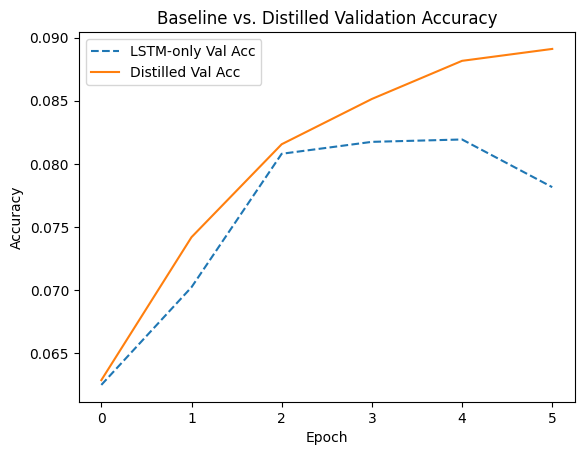

In [ ]:
# === Colab Block 2: Baseline LSTM-only Model ===

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

# 1. Build the baseline LSTM model
baseline_inp = Input(shape=(max_len-1,), name="baseline_input")
b = Embedding(voc, 200)(baseline_inp)
b = LSTM(256)(b)
b = Dropout(0.2)(b)
baseline_out = Dense(voc, activation='softmax')(b)
baseline_model = Model(baseline_inp, baseline_out, name="LSTM_baseline")
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

# 2. Train baseline
baseline_history = baseline_model.fit(X, y, epochs=50, validation_split=0.2,
                                      callbacks=[rlrong, estop])

# 3. Compare Validation Accuracy
plt.plot(baseline_history.history['val_accuracy'], '--', label='LSTM-only Val Acc')
plt.plot(distiller_history.history['val_student_accuracy'], '-', label='Distilled Val Acc')
plt.title('Baseline vs. Distilled Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
